# 08 — Final Comparison of Baseline Models, Time-Series Foundation Models, and TabPFN

This notebook summarizes the results from all forecasting models evaluated in this project. It reads the results generated by notebooks `02`–`07` from `../results/comparison.csv` and produces the tables and figures used in the final analysis. The notebook is designed to work even if some models have not been evaluated, automatically skipping any missing results.

The comparison includes four groups of models. The baseline methods (LightGBM, tuned LightGBM, and MLP) and TabPFN treat PV forecasting as a tabular regression problem using weather and time features as inputs. In contrast, the time-series foundation models (Chronos-2, Moirai, TimesFM, and the fine-tuned Chronos-2 model) use historical power observations together with weather information provided as known future covariates.

All reported metrics correspond to daytime forecasting. The baseline models and TabPFN define daytime using `power > 0`, while the time-series foundation models use a solar elevation threshold (`solar_elevation > 5°`). These definitions produce nearly identical evaluation periods and are consistent with the methodology used in their respective experiments.

Model performance is compared using `MAE`, `RMSE`, and `nRMSE`, while inference time per 24-hour forecast is reported as a measure of computational cost.

## 1. Load `comparison.csv`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re, os

os.makedirs('../figure', exist_ok=True)
plt.rcParams.update({'font.size': 10, 'axes.titlesize': 11, 'axes.labelsize': 10, 'figure.dpi': 120})

# Test window = 2020-01-01 -> 2020-08-01 = 213 days. Used to amortise each model's total
# inference time into a per-24h-forecast figure (the benchmark's cost metric).
N_TEST_DAYS = 213

comp = pd.read_csv('../results/comparison.csv')
# keep last occurrence per model, drop any accidental all-hours rows
comp = comp[~comp['Model'].str.contains('all-h', case=False, na=False)]
comp = comp.drop_duplicates('Model', keep='last').reset_index(drop=True)
print(comp.to_string(index=False))

                   Model      MAE     RMSE    nRMSE  Train Time  Inference Time
                LightGBM 0.021175 0.034823 0.040512    0.776353        0.014204
        LightGBM (tuned) 0.020895 0.034539 0.040182   48.507317        0.033761
                     MLP 0.020945 0.034464 0.040095    3.505997        0.009781
   Chronos-2 (zero-shot) 0.030790 0.061026 0.070997    0.000000       27.479502
Moirai-1.1-R (zero-shot) 0.188942 0.248844 0.289499    0.000000     1053.703917
 TimesFM-2.5 (zero-shot) 0.034216 0.064202 0.074691    0.000000       17.898780
                  TabPFN 0.019900 0.033954 0.039501   12.799952        6.955939
  Chronos-2 (fine-tuned) 0.028074 0.054108 0.062948  523.439313       76.565397


## 2. Categorise models + ordering

In [2]:
PALETTE = {
    'Baseline'         : '#2196F3',
    'TSFM (zero-shot)' : '#FF6B35',
    'TSFM (fine-tuned)': '#4CAF50',
    'Tabular FM'       : '#9C27B0',
}

def categorise(name):
    n = name.lower()
    if any(k in n for k in ['fine', 'finetun', 'lora', '(ft']):  return 'TSFM (fine-tuned)'
    if 'tabpfn' in n:                                            return 'Tabular FM'
    if any(k in n for k in ['lightgbm', 'mlp', 'linear', 'xgb', 'lgbm']): return 'Baseline'
    if any(k in n for k in ['chronos', 'moirai', 'timesfm', 'tsfm']):     return 'TSFM (zero-shot)'
    return 'Baseline'

def clean_name(name):
    s = re.sub(r'\s*\(zero-shot\)', '', name)
    s = s.replace('Moirai-1.1-R', 'Moirai').replace('TimesFM-2.5', 'TimesFM')
    return s.strip()

comp['Category'] = comp['Model'].map(categorise)
comp['Label']    = comp['Model'].map(clean_name)
comp['per24']    = comp['Inference Time'] / N_TEST_DAYS      # amortised inference / 24h forecast

# order best -> worst by nRMSE
comp = comp.sort_values('nRMSE').reset_index(drop=True)
comp['color'] = comp['Category'].map(PALETTE)

def legend_for(df):
    return [mpatches.Patch(color=PALETTE[k], label=k) for k in PALETTE
            if (df['Category'] == k).any()]

print('Order (best -> worst nRMSE):', comp['Label'].tolist())
comp[['Label', 'Category', 'MAE', 'RMSE', 'nRMSE', 'Train Time', 'per24']]

Order (best -> worst nRMSE): ['TabPFN', 'MLP', 'LightGBM (tuned)', 'LightGBM', 'Chronos-2 (fine-tuned)', 'Chronos-2', 'TimesFM', 'Moirai']


,Label,Category,MAE,RMSE,nRMSE,Train Time,per24
0,TabPFN,Tabular FM,0.019900,0.033954,0.039501,12.799952,0.032657
1,MLP,Baseline,0.020945,0.034464,0.040095,3.505997,0.000046
2,LightGBM (tuned),Baseline,0.020895,0.034539,0.040182,48.507317,0.000159
3,LightGBM,Baseline,0.021175,0.034823,0.040512,0.776353,0.000067
4,Chronos-2 (fine-tuned),TSFM (fine-tuned),0.028074,0.054108,0.062948,523.439313,0.359462
5,Chronos-2,TSFM (zero-shot),0.030790,0.061026,0.070997,0.000000,0.129012
6,TimesFM,TSFM (zero-shot),0.034216,0.064202,0.074691,0.000000,0.084032
7,Moirai,TSFM (zero-shot),0.188942,0.248844,0.289499,0.000000,4.946967


## 3. Figure 1 — nRMSE (headline)

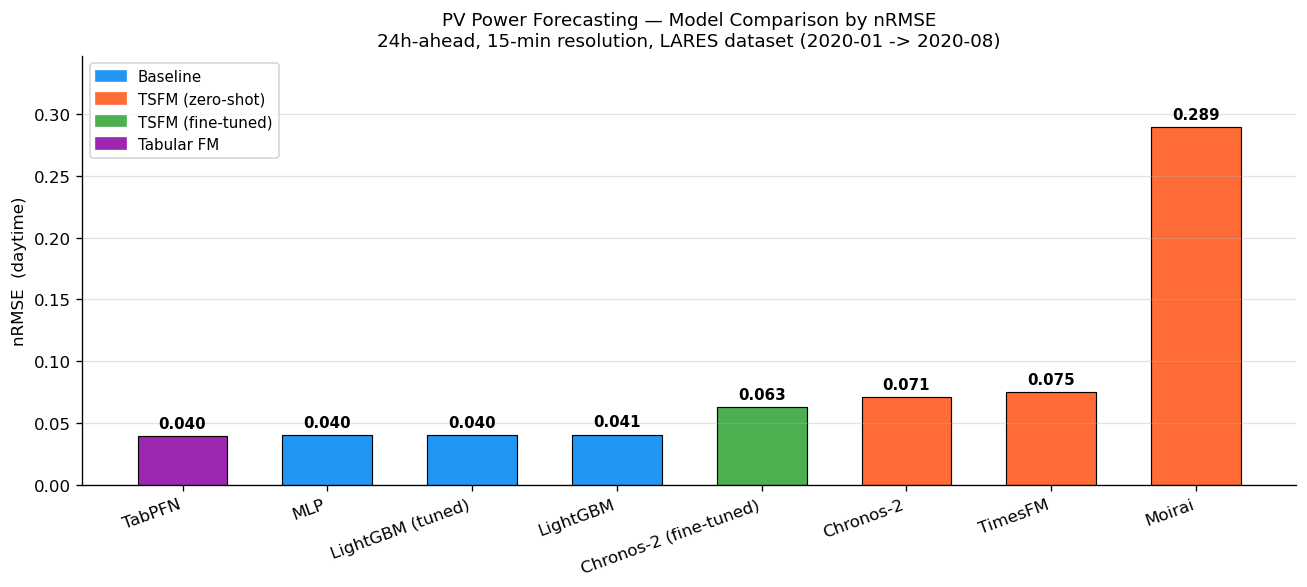

Saved -> ../figure/08_nrmse_comparison.png


In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(comp['Label'], comp['nRMSE'], color=comp['color'],
              edgecolor='black', linewidth=0.7, width=0.62)
for b, v in zip(bars, comp['nRMSE']):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + comp['nRMSE'].max()*0.015,
            f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('nRMSE  (daytime)')
ax.set_title('PV Power Forecasting — Model Comparison by nRMSE\n'
             '24h-ahead, 15-min resolution, LARES dataset (2020-01 -> 2020-08)')
ax.set_xticks(range(len(comp)))
ax.set_xticklabels(comp['Label'], rotation=20, ha='right')
ax.legend(handles=legend_for(comp), fontsize=9, loc='upper left')
ax.set_ylim(0, comp['nRMSE'].max() * 1.20)
ax.grid(axis='y', alpha=0.35); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../figure/08_nrmse_comparison.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved -> ../figure/08_nrmse_comparison.png')

## 4. Figure 2 — MAE / RMSE / nRMSE

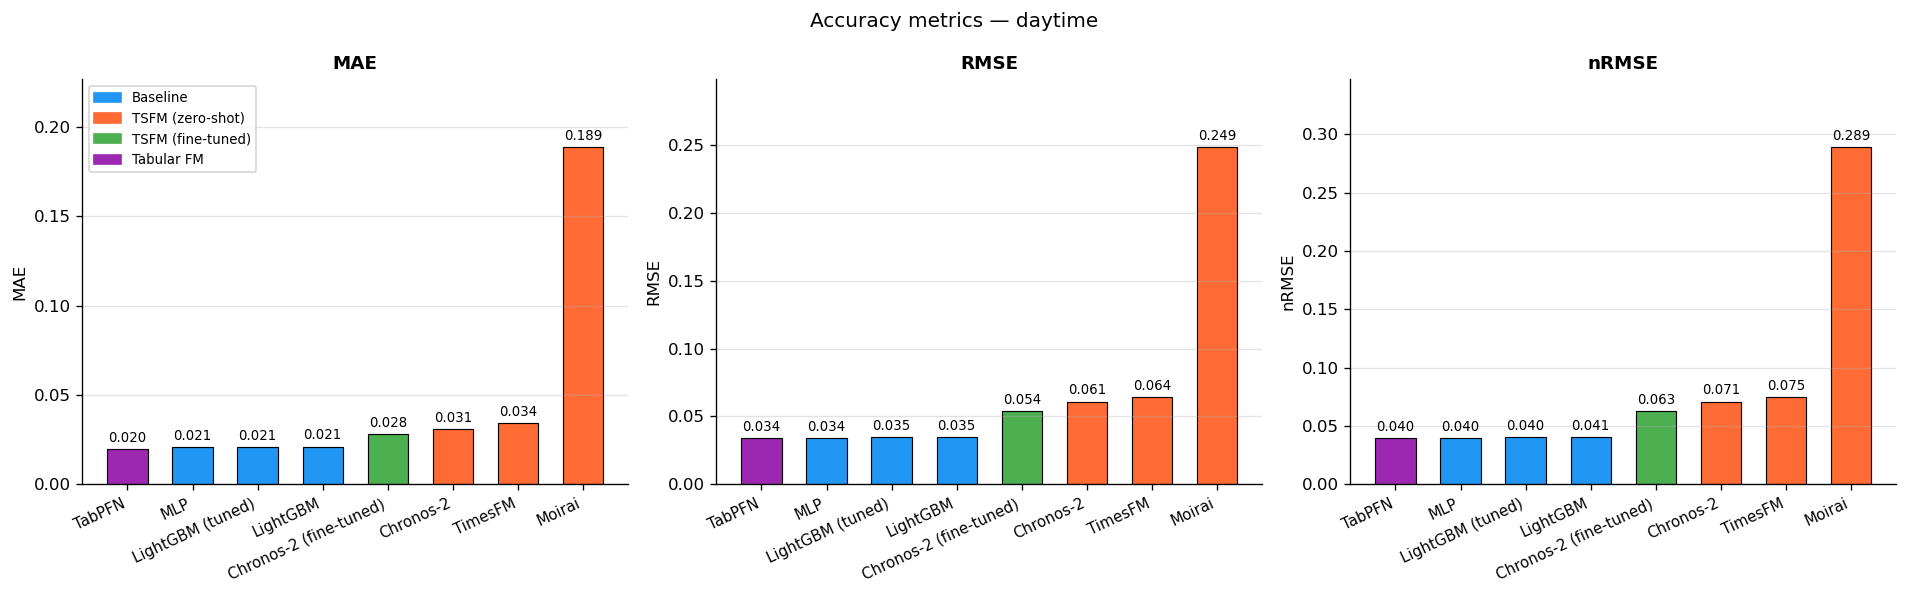

Saved -> ../figure/08_all_metrics.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'nRMSE']):
    bars = ax.bar(comp['Label'], comp[metric], color=comp['color'],
                  edgecolor='black', linewidth=0.7, width=0.62)
    for b, v in zip(bars, comp[metric]):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + comp[metric].max()*0.012,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(metric, fontweight='bold'); ax.set_ylabel(metric)
    ax.set_xticks(range(len(comp)))
    ax.set_xticklabels(comp['Label'], rotation=25, ha='right', fontsize=9)
    ax.set_ylim(0, comp[metric].max() * 1.20)
    ax.grid(axis='y', alpha=0.35); ax.spines[['top', 'right']].set_visible(False)
axes[0].legend(handles=legend_for(comp), fontsize=8)
fig.suptitle('Accuracy metrics — daytime', fontsize=12)
plt.tight_layout()
plt.savefig('../figure/08_all_metrics.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved -> ../figure/08_all_metrics.png')

## 5. Figure 3 — cost vs accuracy trade-off (inference + training, Pareto)

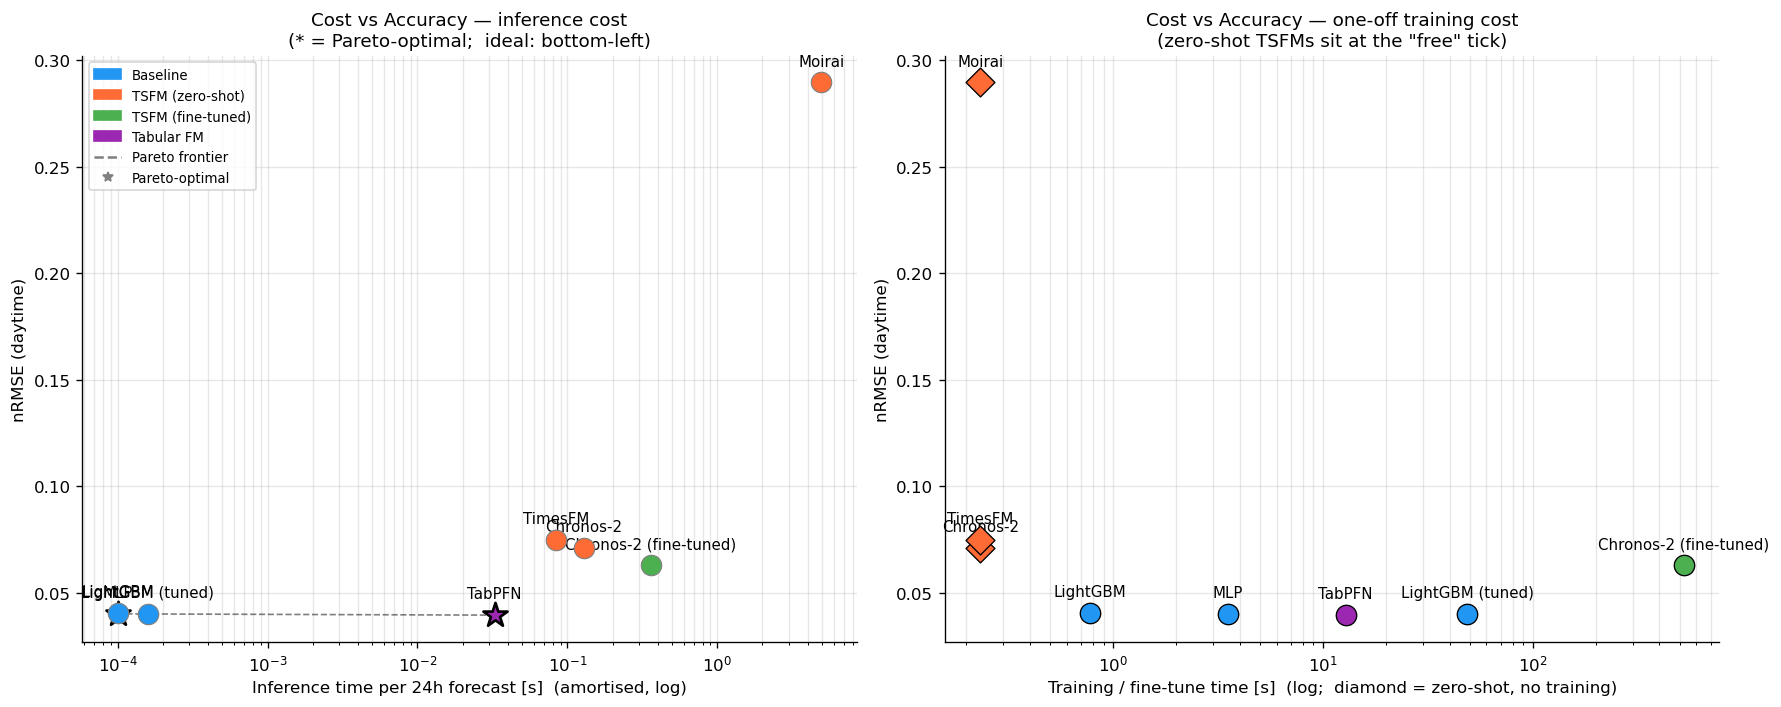

Saved -> ../figure/08_cost_vs_accuracy.png

COST vs ACCURACY VERDICT
  Pareto-optimal (infer cost vs nRMSE): TabPFN, MLP
  Most accurate  : TabPFN                 nRMSE 0.040 at 0.033s/24h
  Cheapest infer : MLP                    0.000s/24h at nRMSE 0.040
  -> the most accurate model costs ~711x the inference of the cheapest; weigh that against its nRMSE gain for the report.


In [5]:
# ---- Cost vs Accuracy trade-off ----
# Two costs matter: (1) RECURRING inference cost per 24h forecast, and (2) ONE-OFF training /
# fine-tune cost. Accuracy = nRMSE (lower is better). A model is *Pareto-optimal* if no other model
# is both cheaper AND more accurate -- those define the efficient frontier.

def pareto_mask(cost, err):
    cost, err = np.asarray(cost, float), np.asarray(err, float)
    keep = np.ones(len(cost), bool)
    for i in range(len(cost)):
        for j in range(len(cost)):
            if j != i and cost[j] <= cost[i] and err[j] <= err[i] and (cost[j] < cost[i] or err[j] < err[i]):
                keep[i] = False; break
    return keep

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# -- Panel A: inference cost (per 24h) vs nRMSE  (the benchmark's headline cost metric) --
ax = axes[0]
xin = comp['per24'].clip(lower=1e-4)
pm  = pareto_mask(xin.values, comp['nRMSE'].values)
for (_, r), on in zip(comp.iterrows(), pm):
    ax.scatter(max(r['per24'], 1e-4), r['nRMSE'], color=r['color'],
               s=(230 if on else 150), marker=('*' if on else 'o'),
               edgecolors=('black' if on else 'grey'), linewidths=(1.6 if on else 0.7), zorder=5)
    ax.annotate(r['Label'], (max(r['per24'], 1e-4), r['nRMSE']),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)
fr = comp[pm].assign(_x=xin[pm]).sort_values('_x')
ax.plot(fr['_x'], fr['nRMSE'], 'k--', alpha=0.5, lw=1, zorder=3)
ax.set_xscale('log')
ax.set_xlabel('Inference time per 24h forecast [s]  (amortised, log)')
ax.set_ylabel('nRMSE (daytime)')
ax.set_title('Cost vs Accuracy — inference cost\n(* = Pareto-optimal;  ideal: bottom-left)')
ax.legend(handles=legend_for(comp) + [
    plt.Line2D([0],[0], ls='--', c='k', alpha=0.5, label='Pareto frontier'),
    plt.Line2D([0],[0], marker='*', ls='', c='grey', label='Pareto-optimal')], fontsize=8)
ax.grid(True, which='both', alpha=0.3); ax.spines[['top', 'right']].set_visible(False)

# -- Panel B: one-off training / fine-tune cost vs nRMSE (zero-shot models train for free) --
ax = axes[1]
pos = comp['Train Time'].replace(0, np.nan)
floor = (pos.min() * 0.3) if pos.notna().any() else 0.1     # place zero-shot (0s) at a left "free" tick
for _, r in comp.iterrows():
    trained = bool(r['Train Time'] and r['Train Time'] > 0)
    x = r['Train Time'] if trained else floor
    ax.scatter(x, r['nRMSE'], color=r['color'], s=150, marker=('o' if trained else 'D'),
               edgecolors='black', linewidth=0.8, zorder=5)
    ax.annotate(r['Label'], (x, r['nRMSE']), textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=9)
ax.set_xscale('log')
ax.set_xlabel('Training / fine-tune time [s]  (log;  diamond = zero-shot, no training)')
ax.set_ylabel('nRMSE (daytime)')
ax.set_title('Cost vs Accuracy — one-off training cost\n(zero-shot TSFMs sit at the "free" tick)')
ax.grid(True, which='both', alpha=0.3); ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../figure/08_cost_vs_accuracy.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved -> ../figure/08_cost_vs_accuracy.png')

# -- Printed efficiency verdict --
best = comp.loc[comp['nRMSE'].idxmin()]
chp  = comp.loc[comp['per24'].idxmin()]
print('\nCOST vs ACCURACY VERDICT')
print(f"  Pareto-optimal (infer cost vs nRMSE): {', '.join(comp[pm]['Label'].tolist())}")
print(f"  Most accurate  : {best['Label']:<22} nRMSE {best['nRMSE']:.3f} at {best['per24']:.3f}s/24h")
print(f"  Cheapest infer : {chp['Label']:<22} {chp['per24']:.3f}s/24h at nRMSE {chp['nRMSE']:.3f}")
speedup = best['per24'] / max(chp['per24'], 1e-6)
print(f"  -> the most accurate model costs ~{speedup:.0f}x the inference of the cheapest; "
      f"weigh that against its nRMSE gain for the report.")

## 6. Figure 4 — zero-shot vs fine-tuned (auto, if present)

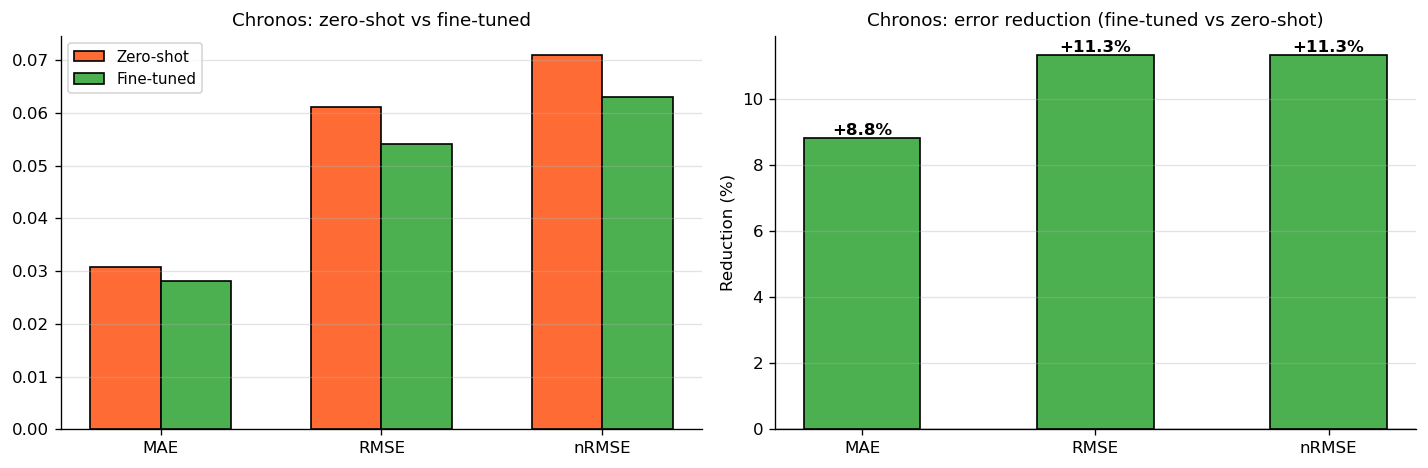

Saved -> ../figure/08_zeroshot_vs_finetuned.png


In [6]:
# Zero-shot vs fine-tuned: auto-detect any fine-tuned row and pair it with its zero-shot base.
ft = comp[comp['Category'] == 'TSFM (fine-tuned)']
pairs = []
for _, frow in ft.iterrows():
    base_kw = next((k for k in ['chronos', 'moirai', 'timesfm'] if k in frow['Model'].lower()), None)
    if base_kw is None:
        continue
    zs = comp[(comp['Category'] == 'TSFM (zero-shot)') &
              (comp['Model'].str.lower().str.contains(base_kw))]
    if len(zs):
        pairs.append((base_kw.capitalize(), zs.iloc[0], frow))

if not pairs:
    print('No fine-tuned row found yet (run 07) -> skipping zero-shot vs fine-tuned figure.')
else:
    metrics = ['MAE', 'RMSE', 'nRMSE']
    fig, axes = plt.subplots(1, 2*len(pairs), figsize=(12*len(pairs), 4))
    axes = np.atleast_1d(axes)
    for j, (base, zs, fr) in enumerate(pairs):
        zv = [zs[m] for m in metrics]; fv = [fr[m] for m in metrics]
        imp = [(z-f)/z*100 if z else 0 for z, f in zip(zv, fv)]
        a0, a1 = axes[2*j], axes[2*j+1]
        xx, w = np.arange(3), 0.32
        a0.bar(xx-w/2, zv, w, label='Zero-shot', color='#FF6B35', edgecolor='black')
        a0.bar(xx+w/2, fv, w, label='Fine-tuned', color='#4CAF50', edgecolor='black')
        a0.set_xticks(xx); a0.set_xticklabels(metrics)
        a0.set_title(f'{base}: zero-shot vs fine-tuned'); a0.legend(fontsize=9)
        a0.grid(axis='y', alpha=0.35); a0.spines[['top','right']].set_visible(False)
        bc = ['#4CAF50' if p > 0 else '#f44336' for p in imp]
        a1.bar(metrics, imp, color=bc, edgecolor='black', width=0.5)
        a1.axhline(0, color='black', lw=0.8)
        a1.set_title(f'{base}: error reduction (fine-tuned vs zero-shot)')
        a1.set_ylabel('Reduction (%)'); a1.grid(axis='y', alpha=0.35)
        a1.spines[['top','right']].set_visible(False)
        for i, p in enumerate(imp):
            a1.text(i, p, f'{p:+.1f}%', ha='center',
                    va='bottom' if p >= 0 else 'top', fontweight='bold')
    plt.tight_layout()
    plt.savefig('../figure/08_zeroshot_vs_finetuned.png', dpi=150, bbox_inches='tight'); plt.show()
    print('Saved -> ../figure/08_zeroshot_vs_finetuned.png')

## 7. Figure 5 — sample sunny-day overlay

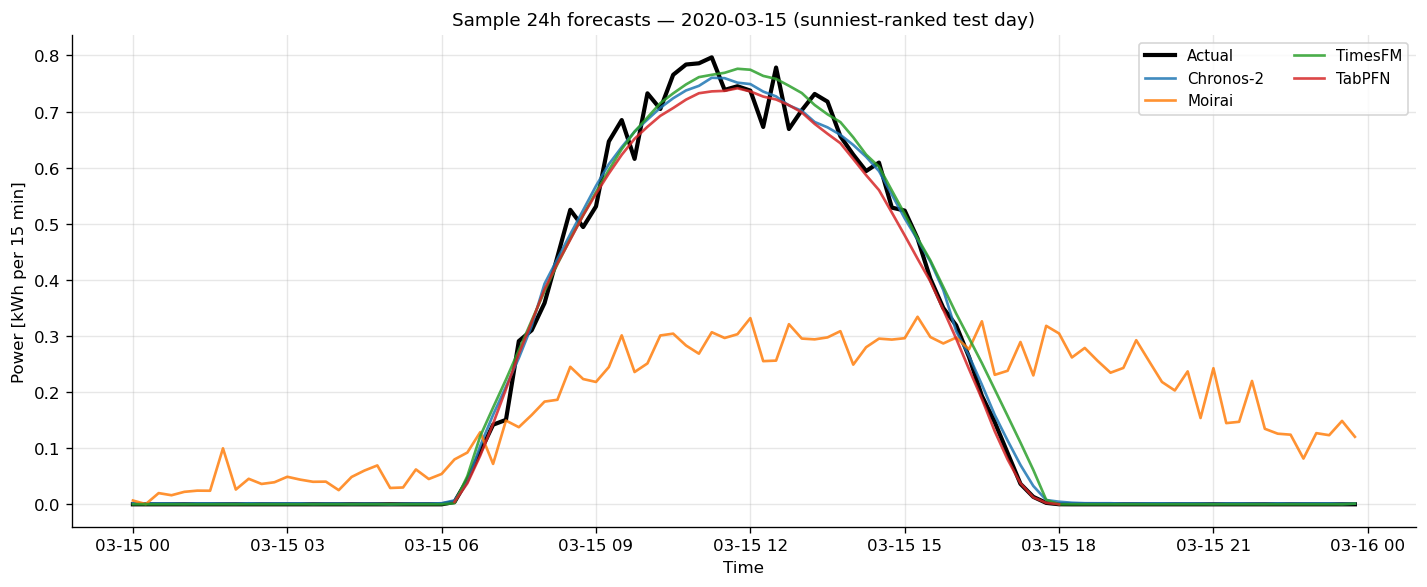

Saved -> ../figure/08_sample_day_overlay.png  (day = 2020-03-15)


In [7]:
# Sample sunny-day overlay from prediction pickles that carry a 'timestamp' column
# (chronos2 / moirai / timesfm / tabpfn). Best-effort; models without timestamps are skipped.
CANDIDATES = {
    'Chronos-2': ('../results/chronos2_predictions.pkl', 'chronos2'),
    'Moirai'   : ('../results/moirai_predictions.pkl',   'moirai'),
    'TimesFM'  : ('../results/timesfm_predictions.pkl',  'timesfm'),
    'TabPFN'   : ('../results/tabpfn_predictions.pkl',   'tabpfn'),
}
loaded = {}
for name, (path, col) in CANDIDATES.items():
    if os.path.exists(path):
        d = pd.read_pickle(path)
        if 'timestamp' in d.columns and col in d.columns:
            d = d.copy(); d['timestamp'] = pd.to_datetime(d['timestamp'])
            loaded[name] = (d, col)

if not loaded:
    print('No timestamped prediction pickles found yet -> skipping overlay.')
else:
    # pick a sunny day: highest daily peak actual, from the first loaded model
    ref, refcol = next(iter(loaded.values()))
    ref = ref.copy(); ref['date'] = ref['timestamp'].dt.date
    peaks = ref.groupby('date')['actual'].max().sort_values(ascending=False)
    day = peaks.index[min(3, len(peaks)-1)]     # 4th-sunniest -> avoids odd extremes
    fig, ax = plt.subplots(figsize=(12, 5))
    plotted_actual = False
    for name, (d, col) in loaded.items():
        sub = d[d['timestamp'].dt.date == day].sort_values('timestamp')
        if sub.empty:
            continue
        if not plotted_actual:
            ax.plot(sub['timestamp'], sub['actual'], 'k-', lw=2.5, label='Actual')
            plotted_actual = True
        ax.plot(sub['timestamp'], sub[col], lw=1.6, alpha=0.85, label=name)
    ax.set_title(f'Sample 24h forecasts — {day} (sunniest-ranked test day)')
    ax.set_xlabel('Time'); ax.set_ylabel('Power [kWh per 15 min]')
    ax.legend(fontsize=9, ncol=2); ax.grid(True, alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('../figure/08_sample_day_overlay.png', dpi=150, bbox_inches='tight'); plt.show()
    print(f'Saved -> ../figure/08_sample_day_overlay.png  (day = {day})')

## 8. Summary table (report-ready)

Saved -> ../results/comparison_summary.csv



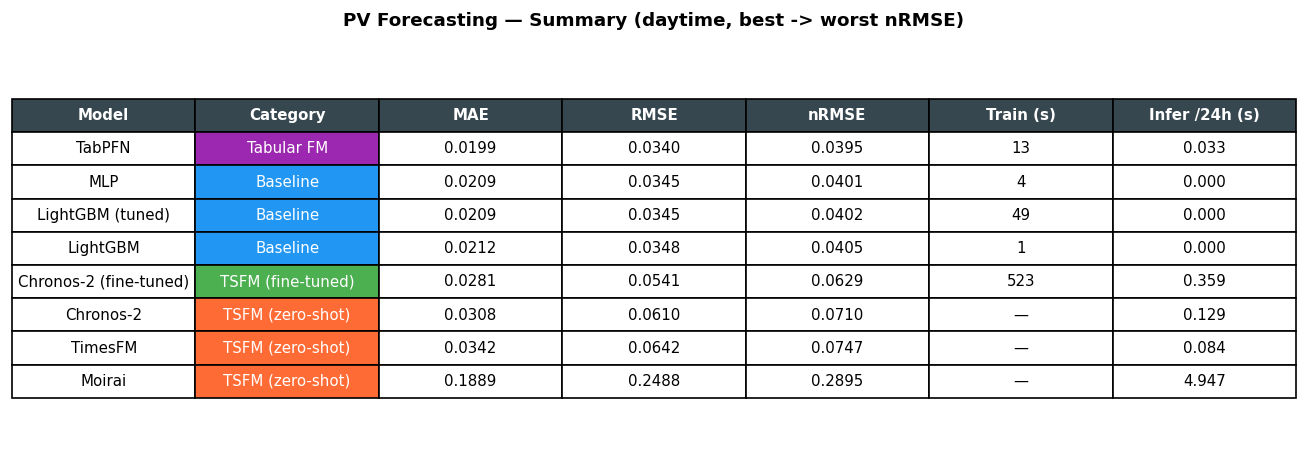

Saved -> ../figure/08_summary_table.png
                 Model          Category    MAE   RMSE  nRMSE Train (s) Infer /24h (s)
                TabPFN        Tabular FM 0.0199 0.0340 0.0395        13          0.033
                   MLP          Baseline 0.0209 0.0345 0.0401         4          0.000
      LightGBM (tuned)          Baseline 0.0209 0.0345 0.0402        49          0.000
              LightGBM          Baseline 0.0212 0.0348 0.0405         1          0.000
Chronos-2 (fine-tuned) TSFM (fine-tuned) 0.0281 0.0541 0.0629       523          0.359
             Chronos-2  TSFM (zero-shot) 0.0308 0.0610 0.0710         —          0.129
               TimesFM  TSFM (zero-shot) 0.0342 0.0642 0.0747         —          0.084
                Moirai  TSFM (zero-shot) 0.1889 0.2488 0.2895         —          4.947


In [8]:
# Report-ready summary table (sorted best -> worst nRMSE), saved as CSV.
tbl = comp[['Label', 'Category', 'MAE', 'RMSE', 'nRMSE', 'Train Time', 'per24']].copy()
tbl.columns = ['Model', 'Category', 'MAE', 'RMSE', 'nRMSE', 'Train (s)', 'Infer /24h (s)']
tbl['Train (s)']      = tbl['Train (s)'].map(lambda x: f'{x:.0f}' if x and x > 0 else '—')
tbl['Infer /24h (s)'] = tbl['Infer /24h (s)'].map(lambda x: f'{x:.3f}')
for m in ['MAE', 'RMSE', 'nRMSE']:
    tbl[m] = tbl[m].map(lambda x: f'{x:.4f}')

out = comp[['Label', 'Category', 'MAE', 'RMSE', 'nRMSE', 'Train Time', 'per24']].copy()
out.columns = ['Model', 'Category', 'MAE', 'RMSE', 'nRMSE', 'Train Time (s)', 'Inference per 24h (s)']
out.to_csv('../results/comparison_summary.csv', index=False)
print('Saved -> ../results/comparison_summary.csv\n')

# render as a figure too
fig, ax = plt.subplots(figsize=(11, 0.6 + 0.42*len(tbl)))
ax.axis('off')
t = ax.table(cellText=tbl.values, colLabels=tbl.columns, cellLoc='center', loc='center')
t.auto_set_font_size(False); t.set_fontsize(9); t.scale(1, 1.5)
for j in range(len(tbl.columns)):
    t[0, j].set_facecolor('#37474F'); t[0, j].set_text_props(color='white', fontweight='bold')
for i, cat in enumerate(comp['Category'], start=1):
    t[i, 1].set_facecolor(PALETTE[cat]); t[i, 1].set_text_props(color='white')
ax.set_title('PV Forecasting — Summary (daytime, best -> worst nRMSE)', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('../figure/08_summary_table.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved -> ../figure/08_summary_table.png')
print(tbl.to_string(index=False))

---
**Saved**: `../figure/08_nrmse_comparison.png`, `08_all_metrics.png`, `08_cost_vs_accuracy.png`,
`08_zeroshot_vs_finetuned.png` (if a fine-tuned row exists), `08_sample_day_overlay.png`,
`08_summary_table.png`, and `../results/comparison_summary.csv`.

Notes for the report: all figures are **daytime** (baseline/TabPFN `power>0`, TSFMs `elev>5°` —
near-identical). Inference time is amortised to **per-24h-forecast** (total ÷ 213 test days) so the
cost axis is comparable across models. If you later add all-hours rows to `comparison.csv`, this
notebook will ignore them (they're filtered out on load); tell me and I can add a daytime-vs-all-hours panel.